In [1]:
pip install mlflow --no-deps

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: C:\Users\sanik\Downloads\churn-prediction\venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
pip install pydantic


[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: C:\Users\sanik\Downloads\churn-prediction\venv\Scripts\python.exe -m pip install --upgrade pip


Data loaded: (5634, 32) train | (1409, 32) test
            
Running grid search
            
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC: nan

Final AUC-ROC:   0.8461
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

            
            


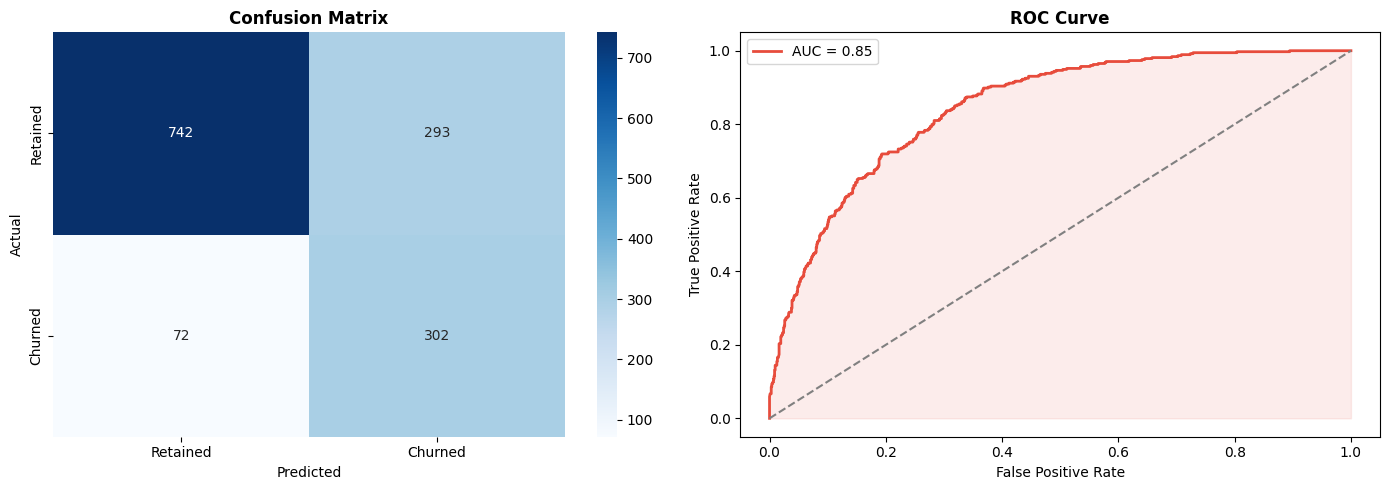

AUC-ROC: 0.8461
model.pkl 
predictions.csv 
experiment_log 


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

# Load data
df = pd.read_csv('../data/processed/features.csv')
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data loaded: {X_train.shape} train | {X_test.shape} test")
print("            ")

# Grid search
focused_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
xgb_base = xgb.XGBClassifier(scale_pos_weight=3, random_state=42,
                               eval_metric='logloss', verbosity=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(xgb_base, focused_grid, cv=cv,
                           scoring='roc_auc', n_jobs=-1, verbose=1)

print("Running grid search")
print("            ")


grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# Final model
best_model = grid_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nFinal AUC-ROC:   {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

print("            ")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
print("            ")


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'AUC = {auc:.2f}')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/05_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
joblib.dump(best_model, '../outputs/model.pkl')

# Save predictions
pred_df = pd.DataFrame({
    'churn_probability': y_pred_proba,
    'predicted_churn': y_pred,
    'actual_churn': y_test.values,
    'tenure': X_test['tenure'].values,
    'MonthlyCharges': X_test['MonthlyCharges'].values,
    'tenure_group': X_test['tenure_group'].values,
    'support_score': X_test['support_score'].values
})
pred_df['risk_tier'] = pd.cut(pred_df['churn_probability'],
                               bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low Risk','Medium Risk','High Risk'])
pred_df.to_csv('../outputs/predictions.csv', index=False)

# Save experiment log
log = {"best_params": grid_search.best_params_,
       "cv_auc": round(grid_search.best_score_, 4),
       "test_auc": round(auc, 4)}
with open('../outputs/experiment_log.json', 'w') as f:
    json.dump(log, f, indent=2)

print(f"AUC-ROC: {auc:.4f}")
print(f"model.pkl ")
print(f"predictions.csv ")
print(f"experiment_log ")